# Grid Search for Hyperparameter Tuning

Most models expose *hyperparameters* — settings we fix before training (a random forest's depth,
its number of trees) rather than values learned from the data. The previous two notebooks left
those settings chosen by hand: `U1-3_Regression-2_Overfitting` found the best complexity by
eyeballing where a test curve peaked, and `U1-3_Regression-1_ModelCompare` simply picked a few
values to compare. That is guesswork, and it does not scale past one hyperparameter.

This notebook replaces it with **grid search and cross-validation**: we hand scikit-learn a grid of
candidate values, it trains and scores a model for every combination on every fold, and it returns
the one that generalizes best.

## Learning objectives

- Define a hyperparameter grid for a `RandomForestRegressor`.
- Use `GridSearchCV` with $k$-fold cross-validation to score every combination.
- Compute the cost of a grid, and explain why it grows multiplicatively.
- Read off the winning hyperparameters and their cross-validated $R^2$.

## Background

This notebook assumes $K$-fold cross-validation, drawn out in `U1-3_Regression-3_CrossValidation`,
and the reason model complexity needs choosing at all, shown in `U1-3_Regression-2_Overfitting`.
Grid search is just those two ideas combined: score every candidate by cross-validation, keep the
best.

**Prerequisites:** `U1-3_Regression-2_Overfitting` (why hyperparameters need tuning),
`U1-3_Regression-3_CrossValidation` (the scoring machinery this uses)

**Dataset:** synthetic — 1,000 points from $y = \sin(\pi x) + \varepsilon$ on $x \in [-2, 2]$ with
Gaussian noise $\varepsilon \sim \mathcal{N}(0, 0.1^2)$.

**References:** https://scikit-learn.org/stable/modules/grid_search.html

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

pd.set_option('display.max_columns',100)
pd.set_option('display.max_rows',100)

plt.style.use('dark_background')

import warnings
warnings.filterwarnings('ignore')

# Shared course helpers (msds565_helpers.py lives in the repo root).
# Notebooks sit two folders below the root, so '../..' points back to it.
import sys
sys.path.append('../..')
import msds565_helpers as helpers

## 1. Create a noisy dataset

A single feature $x$ and a sine-shaped target with a little Gaussian noise — simple enough that we
know the true signal, noisy enough that the hyperparameter choices actually matter.

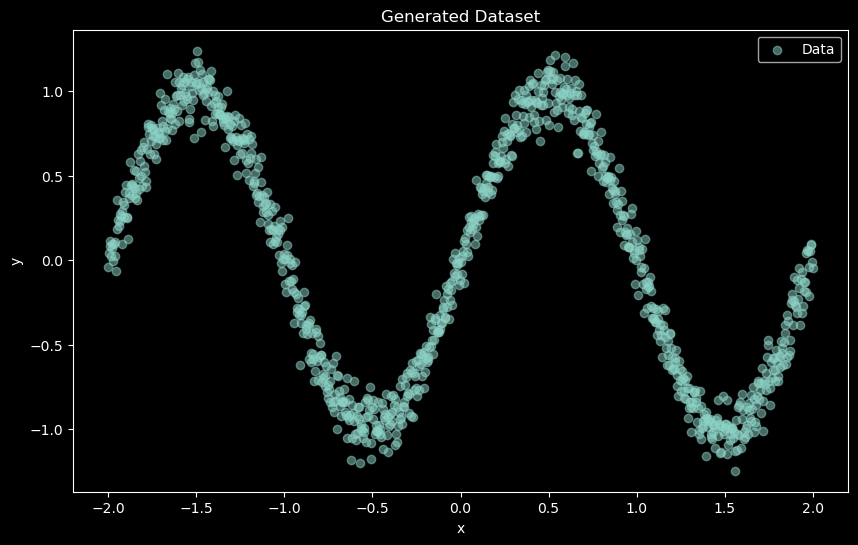

In [2]:
# Generate the data
nPts = 1000
x = np.linspace(-2, 2, nPts)
X = x[:, np.newaxis]                       # sklearn expects a 2-D feature matrix

# Target: one full sine wave per 2 units of x, plus Gaussian noise
y = np.sin(2 * np.pi * x / 2) + np.random.normal(0, 0.1, nPts)

# Plot the data
plt.figure(figsize=(10, 6))
plt.scatter(x, y, label='Data', alpha=0.5)
plt.title("Generated Dataset")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

## 2. Define the model and hyperparameter grid

The estimator is a `RandomForestRegressor`. The grid lists the values to try for four of its
hyperparameters; `GridSearchCV` will take the Cartesian product of these lists.

In [3]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold

# The model whose hyperparameters we are tuning
rf_model = RandomForestRegressor(random_state=42)

# Values to try for each hyperparameter (the Cartesian product = 144 combinations)
param_grid = {
    "n_estimators":      [10, 50, 100, 200],
    "max_depth":         [3, 5, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf":  [1, 2, 4]
}

# 5-fold cross-validation, shuffled so each fold sees the whole x-range
kf = KFold(n_splits=5, shuffle=True, random_state=42)

## 3. Search the grid with cross-validation

Here is the whole method in one line. Given a grid $\Theta$ of hyperparameter combinations, grid
search evaluates each candidate $\theta$ by $K$-fold cross-validation and keeps the one with the
highest mean validation score. With $R^2$ as the score,

$$\hat{\theta} = \arg\max_{\theta \in \Theta}\; \frac{1}{K}\sum_{k=1}^{K}
R^2\!\left(f_\theta^{(-k)},\, \mathcal{D}_k\right),$$

where $f_\theta^{(-k)}$ is the model with hyperparameters $\theta$ trained on every fold except the
$k$-th, and $\mathcal{D}_k$ is that held-out fold. The inner average is exactly the cross-validated
score from `U1-3_Regression-3_CrossValidation`; grid search only adds the $\arg\max$ over $\Theta$.

The cost is the product of everything: $144$ combinations $\times\ 5$ folds $= 720$ model fits.
`n_jobs=-1` spreads them across all available cores.

> **A note on `scoring`.** We select on $R^2$ here because the target is synthetic and unitless, so
> "fraction of variance explained" is as good a summary as any. On a real target with real units
> that choice deserves more thought — `U1_RealEstate-3_Regression` shows a case where selecting on
> $R^2$ and selecting on mean absolute error rank the same models differently, and argues for the
> error metric.

In [4]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, r2_score

grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=kf,
    scoring=make_scorer(r2_score),
    n_jobs=-1,
    verbose=1
)

# This runs all 720 model fits, so it can take a minute
grid_search.fit(X, y)

Fitting 5 folds for each of 144 candidates, totalling 720 fits


,estimator,RandomForestR...ndom_state=42)
,param_grid,"{'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [10, 50, ...]}"
,scoring,make_scorer(r...hod='predict')
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


## 4. Inspect the best model

`GridSearchCV` refits the winning combination on all the data and exposes it, along with the best
hyperparameters and their mean cross-validated score.

In [5]:
# The best hyperparameters and their cross-validated R^2
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best R^2 score:  {grid_search.best_score_:.4f}")

Best parameters: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 200}
Best R^2 score:  0.9785


## 5. Review

- **Grid search turns hyperparameter choice into a search instead of guesswork.** Define a grid, and
  cross-validation scores every combination fairly on held-out folds:
  $\hat{\theta} = \arg\max_{\theta \in \Theta} \frac{1}{K}\sum_k R^2(f_\theta^{(-k)}, \mathcal{D}_k)$.
- **It is cross-validation plus an $\arg\max$** — no new machinery beyond the previous notebook,
  just applied once per candidate.
- We tuned four `RandomForestRegressor` hyperparameters over $4 \times 4 \times 3 \times 3 = 144$
  combinations $\times$ 5 folds, and picked the winner by mean $R^2$.
- **The cost grows multiplicatively.** Adding one more hyperparameter with 4 values quadruples the
  work. Keep grids small and coarse, then refine around the winner — or reach for
  `RandomizedSearchCV`, which samples the space instead of enumerating it, when it gets large.
- **`best_estimator_` is already refit on all the data**, so it is ready to use directly.
- **The metric you search on is the metric you optimize.** It is a real choice, not a default — see
  `U1_RealEstate-3_Regression`.